# 📈 Analyse des Distributions de Prédictions

Objectif : détecter des patterns systématiques dans les probabilités prédites par groupe démographique.

In [1]:
# Cellule 1: Setup
import os, json, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Répertoire de travail = experiments/
if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
# Ajouter utils/ au path Python
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
print(f'📁 Répertoire: {os.getcwd()}')

RESULTS = Path('../results/phase3')
FIGS    = RESULTS / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.calibration import calibration_curve
from fairness_metrics import compute_fairness_metrics
print('✅ Imports OK')


📁 Répertoire: /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
✅ Imports OK


In [2]:
# Cellule 2: Données + embeddings
with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(p):
    data = []
    with open(p, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): data.append(json.loads(line))
    return data

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_test   = le.transform(df_test['title'])
genders  = df_test['gender'].values

# Charger embeddings du meilleur modèle
try:
    with open('../results/phase2/best_embedding_model.json') as f:
        best_info = json.load(f)
    model_id = best_info['model_id']
    print(f'📦 Embeddings: {best_info["label"]}')
except FileNotFoundError:
    model_id = 'distilroberta-base'
    print(f'⚠️  Utilisation de {model_id} par défaut')

safe = model_id.replace('/', '_')
CACHE = Path('embedding_cache')
emb_train = np.load(list(CACHE.glob(f'{safe}_{len(df_train)}*.npy'))[0])
emb_test  = np.load(list(CACHE.glob(f'{safe}_{len(df_test)}*.npy'))[0])
print(f'✅ Embeddings — train: {emb_train.shape}, test: {emb_test.shape}')


📦 Embeddings: DistilRoBERTa
✅ Embeddings — train: (8000, 768), test: (1000, 768)


In [3]:
# Cellule 3: Charger RF
# Charger ou entraîner le meilleur RF sur embeddings
RF_PATH = Path('models/best_rf_embeddings.pkl')

if RF_PATH.exists():
    with open(RF_PATH, 'rb') as f:
        rf = pickle.load(f)
    print('📦 RF chargé depuis cache')
else:
    from sklearn.ensemble import RandomForestClassifier
    try:
        with open('../results/phase2/best_rf_params.json') as f:
            p = json.load(f)
    except FileNotFoundError:
        p = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2}
    rf = RandomForestClassifier(
        n_estimators=p['n_estimators'],
        max_depth=p['max_depth'],
        min_samples_split=p['min_samples_split'],
        random_state=42, n_jobs=-1
    )
    print('🔄 Entraînement RF...')
    rf.fit(emb_train, y_train)
    with open(RF_PATH, 'wb') as f:
        pickle.dump(rf, f)
    print(f'✅ RF entraîné et sauvegardé → {RF_PATH}')

y_pred  = rf.predict(emb_test)
y_proba = rf.predict_proba(emb_test)
print(f'🎯 Accuracy: {(y_pred == y_test).mean():.4f}')


📦 RF chargé depuis cache
🎯 Accuracy: 0.8990


## 📊 Distributions des Probabilités par Groupe

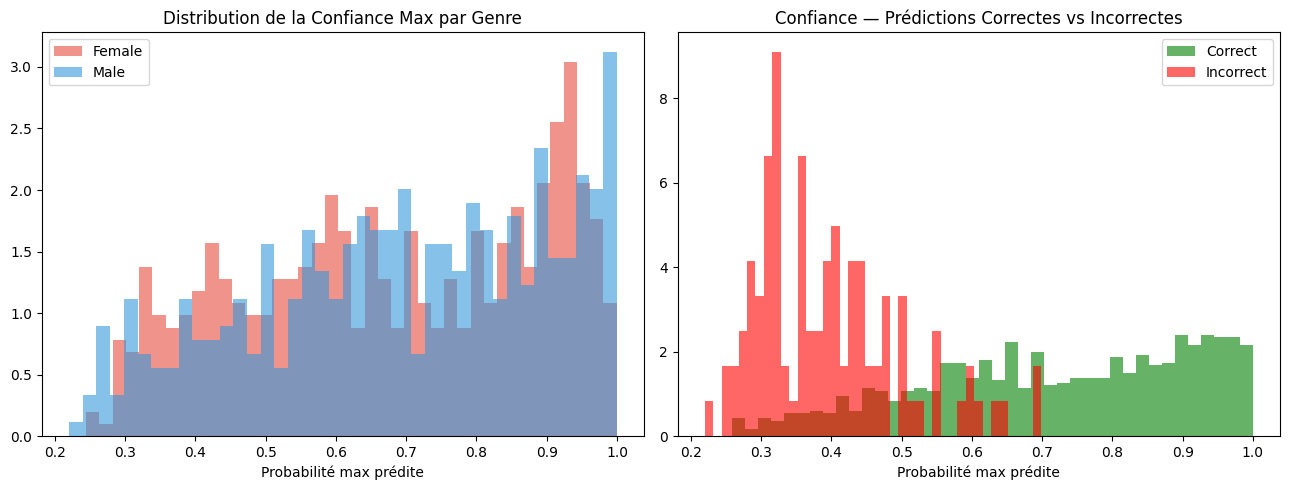

In [4]:
# Cellule 4: Histogrammes probabilité max par genre
max_proba = y_proba.max(axis=1)  # confiance dans la prédiction

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confiance globale par genre
for g, color in [('Female', '#e74c3c'), ('Male', '#3498db')]:
    m = genders == g
    axes[0].hist(max_proba[m], bins=40, alpha=0.6, label=g, color=color, density=True)
axes[0].set_title('Distribution de la Confiance Max par Genre')
axes[0].set_xlabel('Probabilité max prédite')
axes[0].legend()

# Confiance sur les prédictions correctes vs incorrectes
correct = y_pred == y_test
axes[1].hist(max_proba[correct],  bins=40, alpha=0.6, label='Correct',  color='green', density=True)
axes[1].hist(max_proba[~correct], bins=40, alpha=0.6, label='Incorrect', color='red',   density=True)
axes[1].set_title('Confiance — Prédictions Correctes vs Incorrectes')
axes[1].set_xlabel('Probabilité max prédite')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS / 'confidence_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


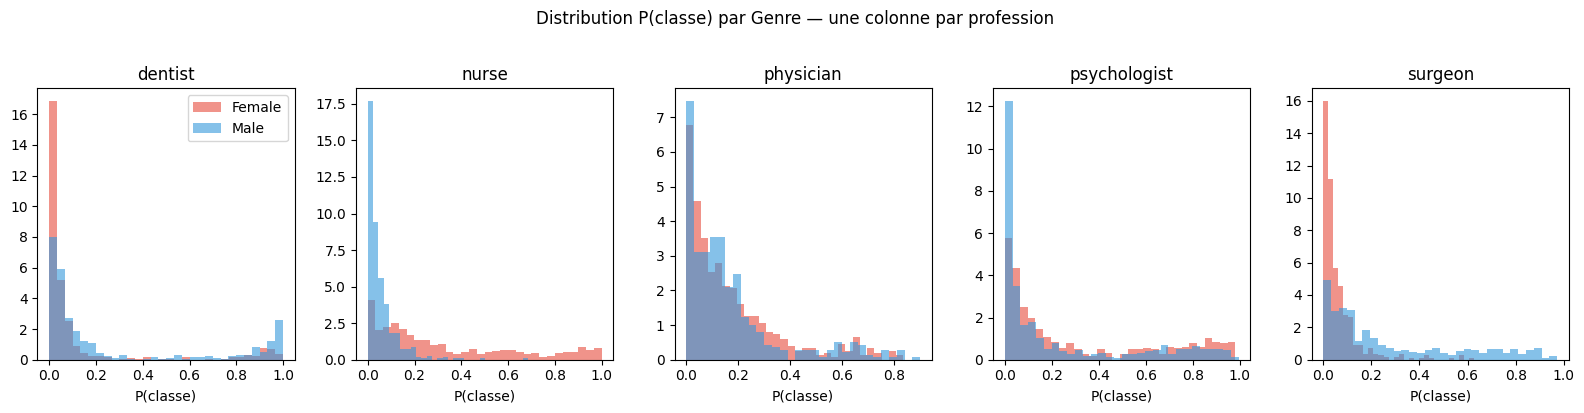

In [5]:
# Cellule 5: Probabilités par classe et par genre
fig, axes = plt.subplots(1, len(le.classes_), figsize=(16, 4))

for cid, (cls, ax) in enumerate(zip(le.classes_, axes)):
    for g, color in [('Female', '#e74c3c'), ('Male', '#3498db')]:
        m = genders == g
        ax.hist(y_proba[m, cid], bins=30, alpha=0.6, label=g, color=color, density=True)
    ax.set_title(cls)
    ax.set_xlabel('P(classe)')
    if cid == 0: ax.legend()

plt.suptitle('Distribution P(classe) par Genre — une colonne par profession', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'proba_by_class_gender.png', dpi=150, bbox_inches='tight')
plt.show()


## 🧪 Tests Statistiques (KS + Mann-Whitney)

In [6]:
# Cellule 6: KS test et Mann-Whitney par classe
print('🧪 TESTS STATISTIQUES — Distribution P(classe) Female vs Male')
print('='*60)

stat_rows = []
for cid, cls in enumerate(le.classes_):
    f_proba = y_proba[genders == 'Female', cid]
    m_proba = y_proba[genders == 'Male',   cid]

    ks_stat,  ks_p  = ks_2samp(f_proba, m_proba)
    mw_stat,  mw_p  = mannwhitneyu(f_proba, m_proba, alternative='two-sided')

    flag = '🚨' if ks_p < 0.01 else ('⚠️' if ks_p < 0.05 else '✅')
    print(f'\n{flag} {cls}:')
    print(f'  KS  stat={ks_stat:.4f}  p={ks_p:.6f}  {"→ distributions DIFFÉRENTES" if ks_p<0.05 else "→ distributions similaires"}')
    print(f'  MW  stat={mw_stat:.1f}  p={mw_p:.6f}')
    print(f'  Mean Female={f_proba.mean():.4f}  Male={m_proba.mean():.4f}  Δ={abs(f_proba.mean()-m_proba.mean()):.4f}')

    stat_rows.append({'profession': cls,
                      'ks_stat': ks_stat, 'ks_p': ks_p,
                      'mw_p': mw_p,
                      'mean_female': f_proba.mean(), 'mean_male': m_proba.mean(),
                      'mean_delta': abs(f_proba.mean()-m_proba.mean())})

stats_df = pd.DataFrame(stat_rows)
print(f'\n🔎 Professions avec distributions significativement différentes (KS p<0.05): '
      f'{(stats_df["ks_p"] < 0.05).sum()}/{len(le.classes_)}')


🧪 TESTS STATISTIQUES — Distribution P(classe) Female vs Male

🚨 dentist:
  KS  stat=0.3065  p=0.000000  → distributions DIFFÉRENTES
  MW  stat=73745.5  p=0.000000
  Mean Female=0.1265  Male=0.2765  Δ=0.1499

🚨 nurse:
  KS  stat=0.5814  p=0.000000  → distributions DIFFÉRENTES
  MW  stat=208989.0  p=0.000000
  Mean Female=0.3228  Male=0.0527  Δ=0.2701

✅ physician:
  KS  stat=0.0654  p=0.226165  → distributions similaires
  MW  stat=128786.0  p=0.313751
  Mean Female=0.1750  Male=0.1688  Δ=0.0062

🚨 psychologist:
  KS  stat=0.2195  p=0.000000  → distributions DIFFÉRENTES
  MW  stat=155161.5  p=0.000000
  Mean Female=0.3138  Male=0.2234  Δ=0.0904

🚨 surgeon:
  KS  stat=0.4644  p=0.000000  → distributions DIFFÉRENTES
  MW  stat=53301.0  p=0.000000
  Mean Female=0.0619  Male=0.2786  Δ=0.2168

🔎 Professions avec distributions significativement différentes (KS p<0.05): 4/5


## 📐 Calibration

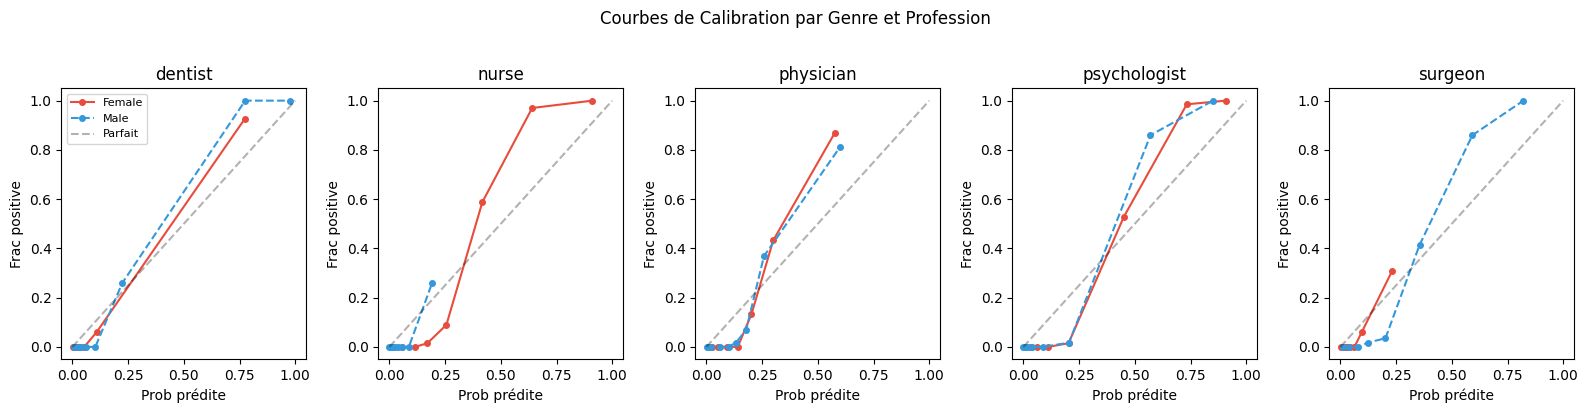

In [7]:
# Cellule 7: Courbes de calibration par classe et genre
fig, axes = plt.subplots(1, len(le.classes_), figsize=(16, 4))

for cid, (cls, ax) in enumerate(zip(le.classes_, axes)):
    for g, color, ls in [('Female','#e74c3c','-'), ('Male','#3498db','--')]:
        m = genders == g
        yt = (y_test[m] == cid).astype(int)
        yp = y_proba[m, cid]
        if yt.sum() > 5:
            frac_pos, mean_pred = calibration_curve(yt, yp, n_bins=8, strategy='quantile')
            ax.plot(mean_pred, frac_pos, marker='o', linestyle=ls, color=color, label=g, markersize=4)
    ax.plot([0,1],[0,1],'k--', alpha=0.3, label='Parfait')
    ax.set_title(cls)
    ax.set_xlabel('Prob prédite')
    ax.set_ylabel('Frac positive')
    if cid == 0: ax.legend(fontsize=8)

plt.suptitle('Courbes de Calibration par Genre et Profession', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# Cellule 8: Sauvegarder
stats_df.to_csv(RESULTS / 'distribution_ks_tests.csv', index=False)

# Stats descriptives par groupe
desc_rows = []
for g in ['Female', 'Male']:
    m = genders == g
    for cid, cls in enumerate(le.classes_):
        p = y_proba[m, cid]
        desc_rows.append({'gender': g, 'profession': cls,
                           'mean': p.mean(), 'std': p.std(),
                           'median': np.median(p), 'q25': np.percentile(p, 25),
                           'q75': np.percentile(p, 75)})
pd.DataFrame(desc_rows).to_csv(RESULTS / 'proba_descriptive_stats.csv', index=False)

print('💾 distribution_ks_tests.csv')
print('💾 proba_descriptive_stats.csv')
print('🎉 Analyse des distributions terminée!')


💾 distribution_ks_tests.csv
💾 proba_descriptive_stats.csv
🎉 Analyse des distributions terminée!
